In [1]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [2]:
import numpy as np  # for numerical operations
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10  # CIFAR-10 dataset
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape)  # training data
print(x_test.shape, y_test.shape)    # testing data

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [4]:
# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [5]:
# Initialize model
model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))  # feature extraction
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# Train model
history = model.fit(
    x_train, y_train,
    epochs=10,  # number of iterations
    batch_size=64,  # samples per batch
    validation_data=(x_test, y_test)  # validation set
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - accuracy: 0.3638 - loss: 1.7185 - val_accuracy: 0.5120 - val_loss: 1.3576
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.5188 - loss: 1.3460 - val_accuracy: 0.5848 - val_loss: 1.1719
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.5853 - loss: 1.1779 - val_accuracy: 0.6259 - val_loss: 1.0513
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.6285 - loss: 1.0684 - val_accuracy: 0.6554 - val_loss: 0.9852
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.6593 - loss: 0.9808 - val_accuracy: 0.6737 - val_loss: 0.9410
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.6844 - loss: 0.9123 - val_accuracy: 0.7003 - val_loss: 0.8710
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.7014 - loss: 0.8606 - val_accuracy: 0.7043 - val_loss: 0.8652
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7168 - loss: 0.8163 - 

In [8]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7025 - loss: 0.8781
Test Accuracy: 0.7024999856948853


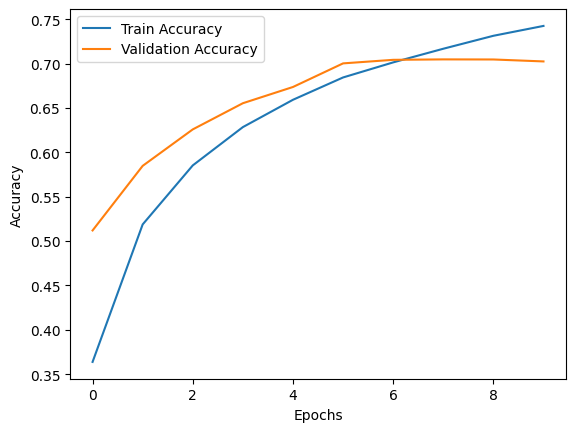

In [9]:
# Plot training vs validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()